### Scott 10K sigdiff (Local Machine version)

#### Only plotting swarmplots
6. Plot swarmplots
    This is the hardest bit because we need swarmplots where all datapoints are plotted
    Need to iterate through various settings
    1 Plot with all datapoints from AD and CN
    1 Plot with those beyond 2 standard deviations cleaned out

In [3]:
import pandas as pd
import numpy as np
import os
import scipy

df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

df = df[df['DIAGNOSIS'].isin([1,3])]

print(df.shape)

cn_df = df[df['DIAGNOSIS'] == 1]

ad_df = df[df['DIAGNOSIS'] == 3]

### Take stock of:

##Number of people with only 1 visit that are CN

counts = cn_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x == 1:
        counter +=1
print(f"Number of people with only 1 visit, and that 1 visit\'s CN: {counter}")

##Number of people with only 1 visit that are AD

counts = ad_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x == 1:
        counter +=1
print(f"Number of people with only 1 visit, and that 1 visit\'s AD: {counter}")

##Number of people with >1 visits all CN
counts = cn_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x != 1:
        counter +=1
print(f"Number of people with >1 visit, all CN: {counter}")

##Number of people with >1 visits all AD

counts = ad_df.groupby('PTID')['DATA_KEY'].count().values

counter = 0
for x in counts:
    if x != 1:
        counter +=1
print(f"Number of people with >1 visit, all AD: {counter}")

##Number of people who convert from CN to AD

counts = df.groupby('PTID')['DIAGNOSIS'].unique().values
counter = 0
for x in counts:
    if len(x) != 1:
        counter +=1
print(f"Number of converters from CN to AD: {counter}")

summary = (
    df.groupby('PTID')['DIAGNOSIS']
      .value_counts()
      .unstack(fill_value=0)
)
summary = summary.rename(columns={1: 'n_CN', 3: 'n_AD'})
converters = summary[(summary['n_CN'] > 0) & (summary['n_AD'] > 0)]

n_conv_1_ad = ((converters['n_AD'] == 1)).sum()
print(f"Converters with exactly 1 AD visit: {n_conv_1_ad}")

n_conv_1_cn = ((converters['n_CN'] == 1)).sum()
print(f"Converters with exactly 1 CN visit: {n_conv_1_cn}")

n_conv_multi_cn = (converters['n_CN'] > 1).sum()
print(f"Converters with >1 CN visits: {n_conv_multi_cn}")

n_conv_multi_ad = (converters['n_AD'] > 1).sum()
print(f"Converters with >1 AD visits: {n_conv_multi_ad}")

n_conv_multi_both = (
    (converters['n_CN'] > 1) & (converters['n_AD'] > 1)
).sum()

print(f"Converters with >1 CN and >1 AD visits: {n_conv_multi_both}")

n_conv_single_both = (
    (converters['n_CN'] == 1) & (converters['n_AD'] == 1)
).sum()

print(f"Converters with 1 CN and 1 AD visit: {n_conv_single_both}")

n_multi_either = (
    (summary['n_CN'] > 1) |
    (summary['n_AD'] > 1)
).sum()

print(f"Patients with >1 CN and/or >1 AD visit: {n_multi_either}")

(6875, 928)
Number of people with only 1 visit, and that 1 visit's CN: 290
Number of people with only 1 visit, and that 1 visit's AD: 166
Number of people with >1 visit, all CN: 693
Number of people with >1 visit, all AD: 576
Number of converters from CN to AD: 28
Converters with exactly 1 AD visit: 15
Converters with exactly 1 CN visit: 3
Converters with >1 CN visits: 25
Converters with >1 AD visits: 13
Converters with >1 CN and >1 AD visits: 12
Converters with 1 CN and 1 AD visit: 2
Patients with >1 CN and/or >1 AD visit: 1257


#### AD and CN swarmplot

In [23]:
from pathlib import Path

Path("C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff").mkdir(
    parents=True,
    exist_ok=True
)

Path("C:/Users/User/Downloads/ephemeral/sankeith/scott_10k_logs/sig_diff").mkdir(
    parents=True,
    exist_ok=True
)

In [24]:
%%file C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

swarmplot_path = 'C:/Users/User/Downloads/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


for coeff_path in ['C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/desikan_coeffs.csv',
                  'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/flipped_desikan_coeffs.csv',
                  'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/destrieux_coeffs.csv',
                  'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/flipped_destrieux_coeffs.csv']:

    df = pd.read_csv(coeff_path, low_memory=False)
    diag_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                          low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

    merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
    cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

    melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

    print(melted_df)

    stats_df = pd.read_csv(
        f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('s.csv', '')}_sig_diff.csv",
        low_memory = False)


    for width in range(50, 60):
        for dot_size in np.arange(0.1, 2.1, 0.1):
            height = (width / 4) 

            print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

            pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

            print(pval_dict)

            assert list(pval_dict.keys()) == cn_ad_df.drop(columns = 'DIAGNOSIS').columns.tolist()

            
            plt.figure(figsize=(width, height))
            
            ax = sns.swarmplot(
                data=melted_df, 
                x = 'NEUROTRANSMITTER', 
                y = 'VALUE', 
                hue ='DIAGNOSIS', 
                palette = {1: 'green', 3: 'red'},
                dodge = True, 
                size = dot_size, 
                alpha = 0.7
            )

            plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')

            # Order + y positions
            x_order = melted_df['NEUROTRANSMITTER'].unique()

            print(x_order)
            y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
            print(y_max)

            y_range = melted_df['VALUE'].max() - melted_df['VALUE'].min()
            bracket_height = 0.01 * y_range  # How tall the "tips" of the bracket are
            bracket_offset = 0.02 * y_range  # Space between data and bracket
            text_offset = 0.005 * y_range 
            
            # Add stars
            for i, nt in enumerate(x_order):
                if nt in pval_dict:
                    stars = get_significance_stars(pval_dict[nt])
                    
                    if stars != 'ns':
                        y_base = y_max[nt] + bracket_offset
                        x1, x2 = i - 0.2, i + 0.2

                        ax.plot([x1, x1, x2, x2], 
                                [y_base - bracket_height, y_base, y_base, y_base - bracket_height], 
                                lw=1.5, color='black')

                        ax.text((x1 + x2) * .5, y_base + text_offset, stars, 
                                ha='center', va='bottom', fontsize=12, fontweight='bold')
                        
                        y = y_max[nt] + 0.02 * (y_max.max() - y_max.min())
                        ax.text(i, y, stars, ha='center', va='bottom', fontsize=10)

            plt.tight_layout()
            final_path = os.path.join(swarmplot_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv', '')}_w{width}_h{height}_d{dot_size:.1f}.png")
            print(final_path)
            plt.savefig(final_path, dpi = 300)
            plt.close()

 

Overwriting C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/swarmplots.py


In [32]:
%%file C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/para_swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

swarmplot_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok=True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

coeff_options = [
    'desikan_coeffs.csv', 'flipped_desikan_coeffs.csv',
    'destrieux_coeffs.csv', 'flipped_destrieux_coeffs.csv'
]
selected_filename = coeff_options[int(sys.argv[1])]
coeff_path = os.path.join('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/', selected_filename)

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns='DATA_KEY')
melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

# 3. Outlier Filtering (Ensures the plot isn't squashed by extreme values)
group_stats = melted_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

# 4. Global Stats (Calculate ONCE before loops)
v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()
y_range = v_max - v_min
x_order = melted_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

print(f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv")
stats_df = pd.read_csv(
    f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv",
    low_memory=False)
pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

# 5. Plotting Loops
for width in range(61, 65, 1):
    for dot_size in [0.6, 0.7, 1]:
        height = max(6, float(width / 4))
        print(f"Plotting {selected_filename}: W={width}, H={height:.1f}, Size={dot_size}")

        plt.figure(figsize=(width, height))

        ax = sns.swarmplot(
            data = melted_df, 
            x='NEUROTRANSMITTER', 
            y = 'VALUE',
            hue = 'DIAGNOSIS', 
            palette={1: 'green', 3: 'red'},
            dodge=True, 
            size=dot_size, 
            alpha=0.7,
            order=x_order
        )

        ax.set_yscale("linear")
        plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
        plt.xlabel('Neurotransmitter map')
        plt.ylabel('Beta coefficient value')
        # Add 5% padding at top for stars
        y_range = v_max - v_min
        padding = y_range * 0.05
        ax.set_ylim(v_min - padding, v_max + padding)

        # 6. Add Brackets and Stars

        y_total_range = v_max - v_min # Fix 1: Use existing global min/max

        for i, nt in enumerate(x_order):
            if nt in pval_dict:
                stars = get_significance_stars(pval_dict[nt])

                if stars != 'ns':
                    # Fix 2: Use y_max_per_nt variable defined in step 4
                    y_base = y_max_per_nt[nt] + 0.02 * y_total_range  
                    y_tips = y_base - 0.01 * y_total_range    

                    x1, x2 = i - 0.2, i + 0.2

                    ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                    ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)

        plt.title(f"Group Comparison: {selected_filename.replace('_coeffs.csv', '')} (Linear Scale)")
        sns.despine()
        plt.legend(['CN', 'AD'], loc = 'upper right', title='Diagnosis')  
        plt.tight_layout()
        save_name = f"{selected_filename.replace('_coeffs.csv', '')}_linear_w{width}_h{height:.1f}_d{dot_size:.2f}.png"
        plt.savefig(os.path.join(swarmplot_path, save_name), dpi=300)
        plt.close()


Overwriting C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/para_swarmplots.py


#### Swarmplots - but data is cleaned to be within 2 standard deviations for each neurotransmitter's distribution

In [33]:
%%file C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/para_c_swarmplots.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)


swarmplot_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok=True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

coeff_options = [
    'desikan_coeffs.csv', 'flipped_desikan_coeffs.csv',
    'destrieux_coeffs.csv', 'flipped_destrieux_coeffs.csv'
]
selected_filename = coeff_options[int(sys.argv[1])]
coeff_path = os.path.join('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/', selected_filename)

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns='DATA_KEY')
melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

group_stats = melted_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')
filtered_df = melted_df[(melted_df['VALUE'] >= means - 2*stds) & (melted_df['VALUE'] <= means + 2*stds)].copy()

v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()
y_range = v_max - v_min
x_order = filtered_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

print(f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv")
stats_df = pd.read_csv(
    f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv",
    low_memory=False)
pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

for width in range(61, 65, 1):
    for dot_size in [0.6, 0.7, 1]:
        height = max(6, float(width / 4))
        print(f"Plotting {selected_filename}: W={width}, H={height:.1f}, Size={dot_size}")

        plt.figure(figsize=(width, height))
        
        ax = sns.swarmplot(
            data=filtered_df, 
            x='NEUROTRANSMITTER', 
            y= 'VALUE',
            hue='DIAGNOSIS', 
            palette={1: 'green', 3: 'red'},
            dodge=True, 
            size=dot_size, 
            alpha=0.7,
            order=x_order
        )

        ax.set_yscale("linear")
        plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
        plt.xlabel('Neurotransmitter map')
        plt.ylabel('Beta coefficient value')
        # Add 5% padding at top for stars
        y_range = v_max - v_min
        padding = y_range * 0.05
        ax.set_ylim(v_min - padding, v_max + padding)

        # 6. Add Brackets and Stars
        
        y_total_range = v_max - v_min # Fix 1: Use existing global min/max
            
        for i, nt in enumerate(x_order):
            if nt in pval_dict:
                stars = get_significance_stars(pval_dict[nt])
                
                if stars != 'ns':
                    # Fix 2: Use y_max_per_nt variable defined in step 4
                    y_base = y_max_per_nt[nt] + 0.02 * y_total_range  
                    y_tips = y_base - 0.01 * y_total_range    
                    
                    x1, x2 = i - 0.2, i + 0.2
                    
                    ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                    ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)

        plt.title(f"Group Comparison: {selected_filename.replace('_coeffs.csv', '')} (Linear Scale)")
        sns.despine()
        plt.legend(['CN', 'AD'], loc = 'upper right', title='Diagnosis')  
        plt.tight_layout()
        save_name = f"{selected_filename.replace('_coeffs.csv', '')}_c_linear_w{width}_h{height:.1f}_d{dot_size:.2f}.png"
        plt.savefig(os.path.join(swarmplot_path, save_name), dpi=300)
        plt.close()

Writing C:/Users/User/Downloads/ephemeral/scott_10k_scripts/sig_diff/para_c_swarmplots.py


#### Some code for specifically plotting desikan_c with different dot sizes


C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/desikan_coeffs_sig_diff.csv
Plotting desikan_coeffs.csv: W=61, H=15.2, Size=1.4


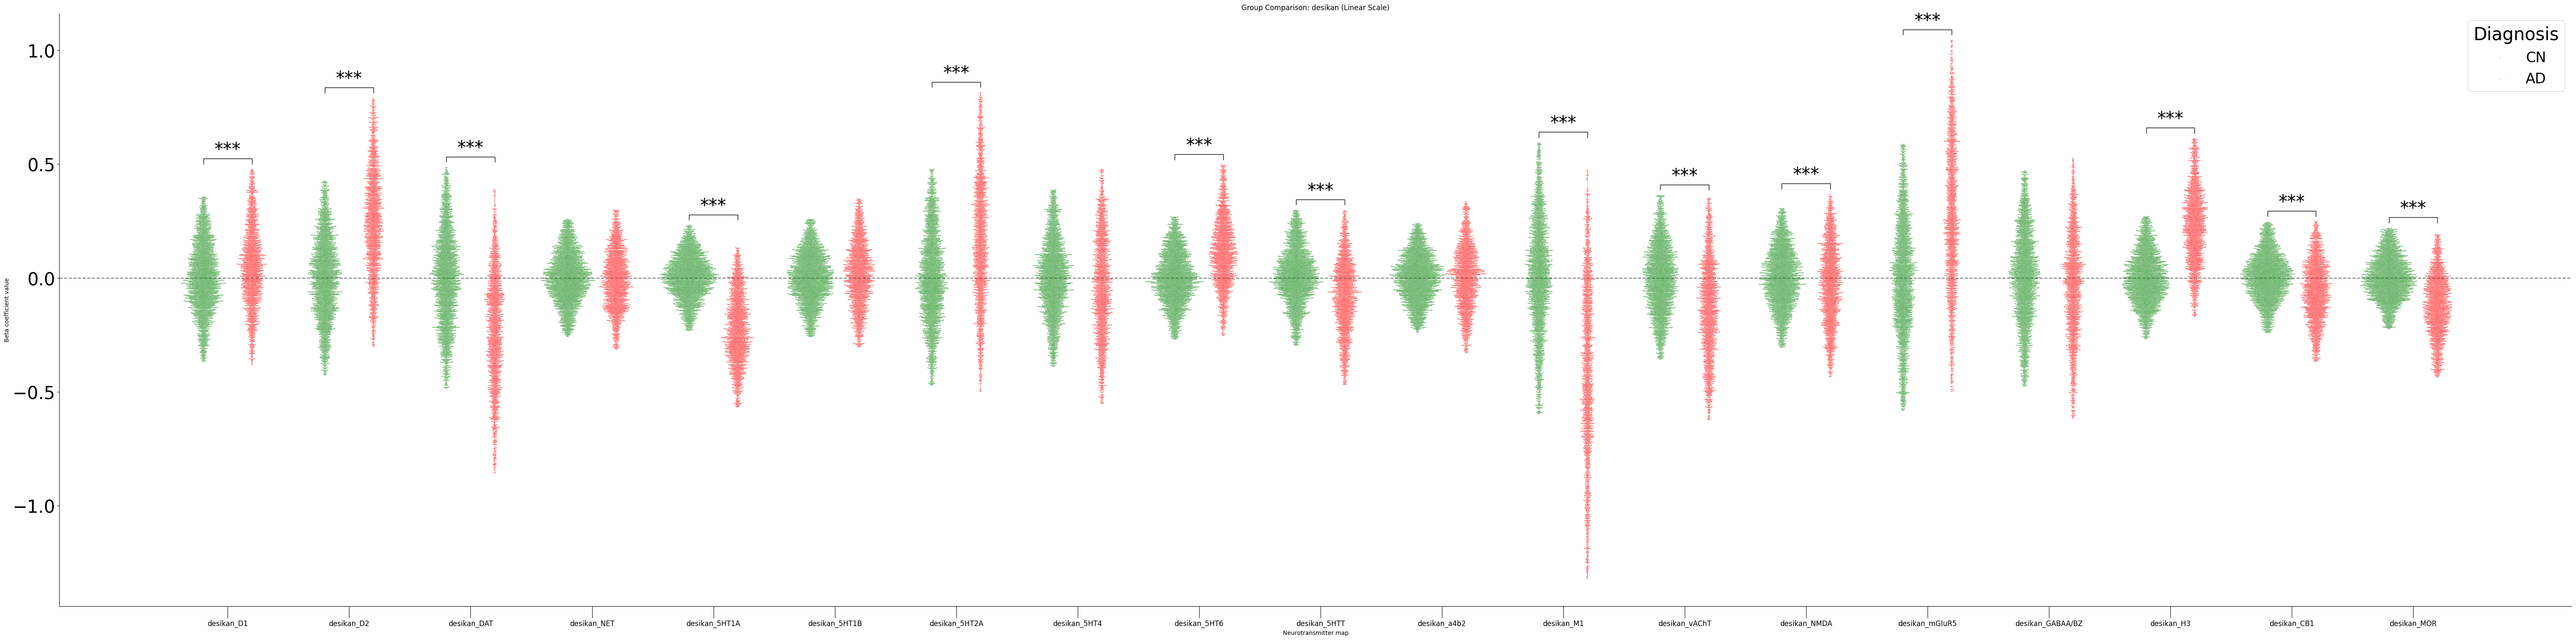

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)


swarmplot_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots'
os.makedirs(swarmplot_path, exist_ok=True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

selected_filename = 'desikan_coeffs.csv'
coeff_path = os.path.join('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/', selected_filename)

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns='DATA_KEY')
melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

group_stats = melted_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')
filtered_df = melted_df[(melted_df['VALUE'] >= means - 2*stds) & (melted_df['VALUE'] <= means + 2*stds)].copy()

v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()
y_range = v_max - v_min
x_order = filtered_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

print(f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv")
stats_df = pd.read_csv(
    f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{selected_filename.replace('.csv', '')}_sig_diff.csv",
    low_memory=False)
pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

width = 61
height = max(6, float(width / 4))
for dot_size in [1.4]:
        
    print(f"Plotting {selected_filename}: W={width}, H={height:.1f}, Size={dot_size}")

    plt.figure(figsize=(width, height))
    
    ax = sns.swarmplot(
        data=filtered_df, 
        x='NEUROTRANSMITTER', 
        y= 'VALUE',
        hue='DIAGNOSIS', 
        palette={1: 'green', 3: 'red'},
        dodge=True, 
        size=dot_size, 
        alpha=0.7,
        order=x_order
    )

    ax.set_yscale("linear")
    plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
    plt.xlabel('Neurotransmitter map')
    plt.ylabel('Beta coefficient value')
    # Add 5% padding at top for stars
    y_range = v_max - v_min
    padding = y_range * 0.05
    ax.set_ylim(v_min - padding, v_max + padding)

    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 30)
    ax.tick_params(axis='x', length = 20)


    # 6. Add Brackets and Stars
    
    y_total_range = v_max - v_min # Fix 1: Use existing global min/max
        
    for i, nt in enumerate(x_order):
        if nt in pval_dict:
            stars = get_significance_stars(pval_dict[nt])
            
            if stars != 'ns':
                # Fix 2: Use y_max_per_nt variable defined in step 4
                y_base = y_max_per_nt[nt] + 0.02 * y_total_range  
                y_tips = y_base - 0.01 * y_total_range    
                
                x1, x2 = i - 0.2, i + 0.2
                
                ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
                ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize = 30)

    plt.title(f"Group Comparison: {selected_filename.replace('_coeffs.csv', '')} (Linear Scale)")
    sns.despine()
    leg = plt.legend(['CN', 'AD'], loc = 'upper right', title='Diagnosis', fontsize = 24)  
    plt.setp(leg.get_title(),fontsize = 30)
    plt.tight_layout()
    save_name = f"{selected_filename.replace('_coeffs.csv', '')}_c_linear_w{width}_h{height:.1f}_d{dot_size:.2f}.png"
    plt.savefig(os.path.join(swarmplot_path, save_name), dpi=300)
    plt.show()
    plt.close()

False
['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']
         Coefficient         Raw_P                  Test   Corrected_P  \
0         desikan_D1  1.860282e-07  Wilcoxon signed-rank  3.534536e-06   
1         desikan_D2  5.743015e-29  Wilcoxon signed-rank  1.091173e-27   
2        desikan_DAT  2.893191e-31  Wilcoxon signed-rank  5.497063e-30   
3        desikan_NET  4.311008e-01  Wilcoxon signed-rank  1.000000e+00   
4      desikan_5HT1A  5.950147e-38  Wilcoxon signed-rank  1.130528e-36   
5      desikan_5HT1B  2.216084e-05  Wilcoxon signed-rank  4.210559e-04   
6      desikan_5HT2A  4.735653e-01  Wilcoxon signed-rank  1.000000e+00   
7       desikan_5HT4  1.582579e-03  Wilcoxon signed-rank  3.006900e-02   
8       desikan_5HT6  4.5

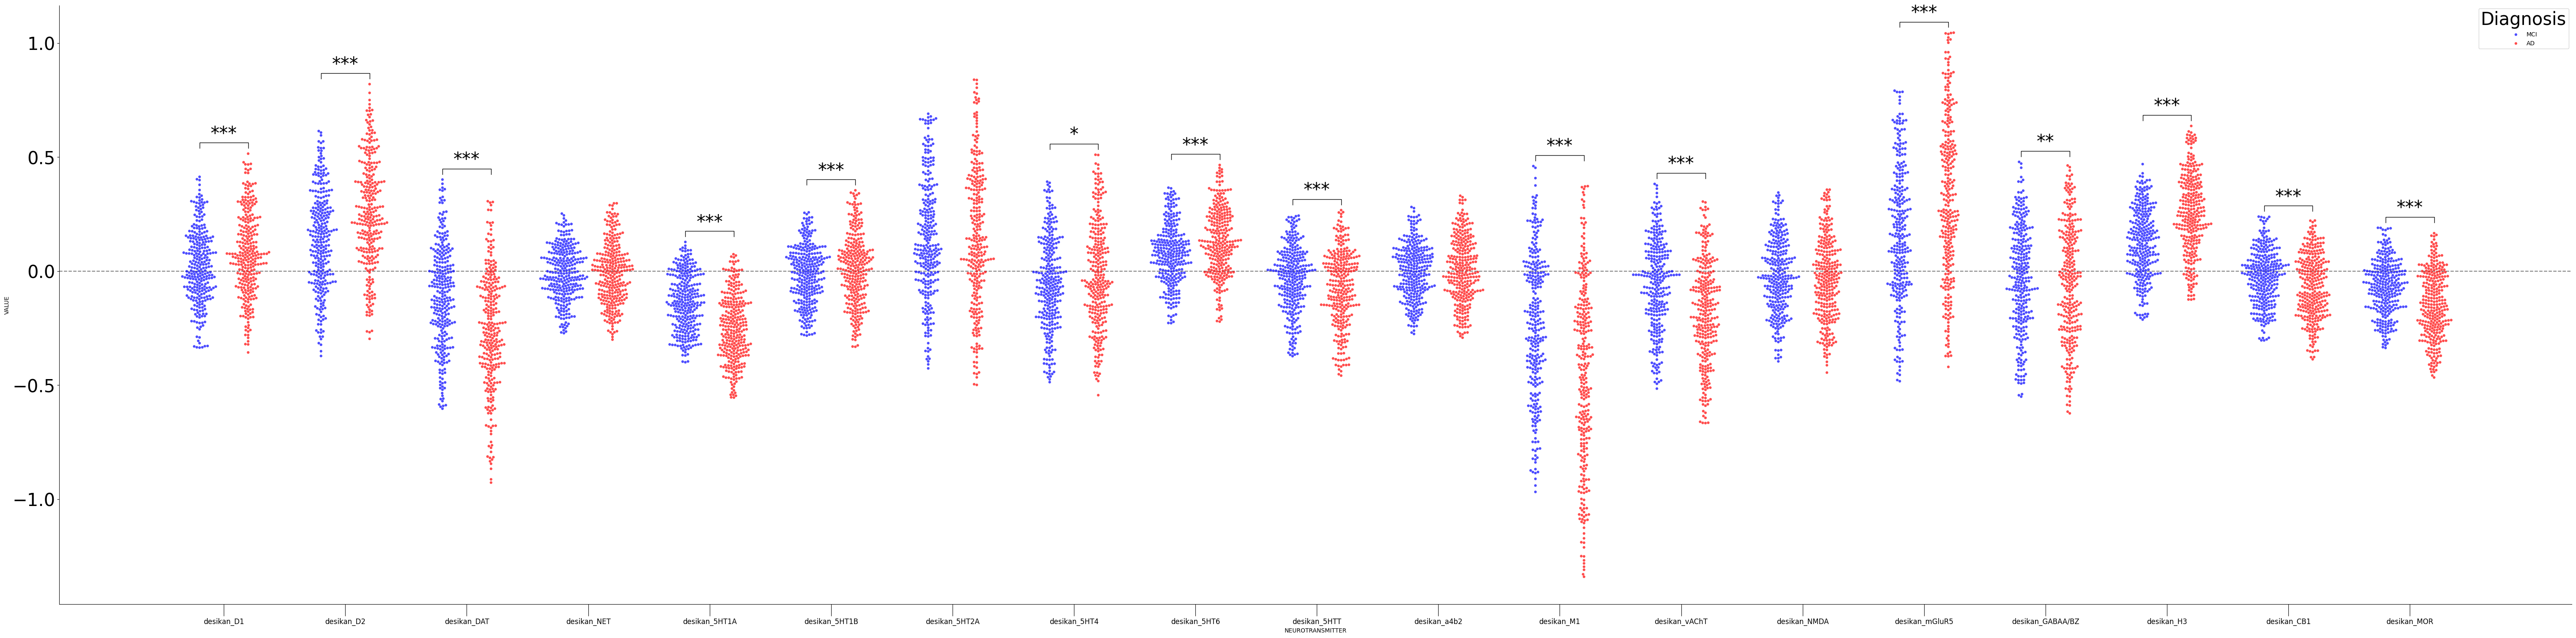

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import shapiro, wilcoxon
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

os.makedirs('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots/', exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


coeff_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_far.csv'

df = pd.read_csv(coeff_path, low_memory=False)

df = df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]

cleaned_df = df[df['DIAGNOSIS_oth'] == 1].reset_index(drop = True)
cleaned_df.drop(columns = 'DIAGNOSIS_oth', inplace = True)
cleaned_df.columns.tolist()

print(cleaned_df.isna().any().all())

root_cols = [col.replace('_mci','') for col in cleaned_df.columns.tolist() if col.endswith('_mci')]
print(root_cols)

stats_results = []
for c in root_cols:
    subset_df = cleaned_df[[col for col in cleaned_df.columns.tolist() if c in col]]
    is_normal = True
    for g in [cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values]:
        d = cleaned_df[f'{c}_mci'].values - cleaned_df[f'{c}_oth'].values
        res = shapiro(d)
        if res.pvalue < 0.05:
            is_normal = False
            break
    if is_normal:
        test_name = 'T-test related'
        _, pval, _ = ttest_rel(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
    else:
        test_name = 'Wilcoxon signed-rank'
        res = wilcoxon(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
        pval = res.pvalue

    stats_results.append({
    'Coefficient': c,
    'Raw_P': pval,
    'Test': test_name})
    
stats_df = pd.DataFrame(stats_results)
    
reject, p_corr, _, _ = multipletests(stats_df['Raw_P'], alpha=0.05, method='bonf')
stats_df['Corrected_P'] = p_corr
stats_df['Significant'] = reject.tolist()#stats_df['Corrected_P'] < 0.05
print(stats_df)
stats_df.to_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', index = False)


cleaned_df = cleaned_df

mci_df = cleaned_df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']]
mci_df.columns = mci_df.columns.map(lambda x : x.replace('_mci', ''))
mci_df['DIAGNOSIS'] = 2
print(mci_df.columns.tolist())

ad_df = cleaned_df[['desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth',	'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]
ad_df.columns = ad_df.columns.map(lambda x : x.replace('_oth', ''))
ad_df['DIAGNOSIS'] = 3
print(ad_df.columns.tolist())

joined_df = pd.concat([mci_df, ad_df], axis = 0)

melted_df = joined_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

filtered_df = melted_df.copy()
group_stats = filtered_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

filtered_df = filtered_df[
    (filtered_df['VALUE'] >= means - 2*stds) &
    (filtered_df['VALUE'] <= means + 2*stds)]


v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()


width = 61
height = max(6, float(width / 4))
dot_size = 4.5

stats_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', low_memory = False)

print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

plt.figure(figsize=(width, height))

v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()
        
ax = sns.swarmplot(
    data=filtered_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {2: 'blue', 3: 'red'},
    dodge = True, 
    size = dot_size, 
    alpha = 0.7
)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 30)
ax.tick_params(axis='x', length = 20)

# Order + y positions
x_order = filtered_df['NEUROTRANSMITTER'].unique()

y_max = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
print(y_max)
        
        
y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)

y_total_range = v_max - v_min # Fix 1: Use existing global min/max
    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':
            
            y_base = y_max[nt] + 0.02 * y_total_range  
            y_tips = y_base - 0.01 * y_total_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=30)


sns.despine()
leg = plt.legend(['MCI', 'AD'], loc = 'upper right', title = 'Diagnosis')
plt.setp(leg.get_title(),fontsize = 30)
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
plt.tight_layout()
final_path = f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots/c_cb_far_w{width}_h{height}_d{dot_size:.1f}.png"
print(final_path)
plt.savefig(final_path, dpi = 600)
plt.show()
plt.close()


False
['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']
         Coefficient         Raw_P                  Test   Corrected_P  \
0         desikan_D1  1.860282e-07  Wilcoxon signed-rank  2.945447e-07   
1         desikan_D2  5.743015e-29  Wilcoxon signed-rank  2.182346e-28   
2        desikan_DAT  2.893191e-31  Wilcoxon signed-rank  1.374266e-30   
3        desikan_NET  4.311008e-01  Wilcoxon signed-rank  4.550508e-01   
4      desikan_5HT1A  5.950147e-38  Wilcoxon signed-rank  1.130528e-36   
5      desikan_5HT1B  2.216084e-05  Wilcoxon signed-rank  3.238891e-05   
6      desikan_5HT2A  4.735653e-01  Wilcoxon signed-rank  4.735653e-01   
7       desikan_5HT4  1.582579e-03  Wilcoxon signed-rank  2.004600e-03   
8       desikan_5HT6  4.5

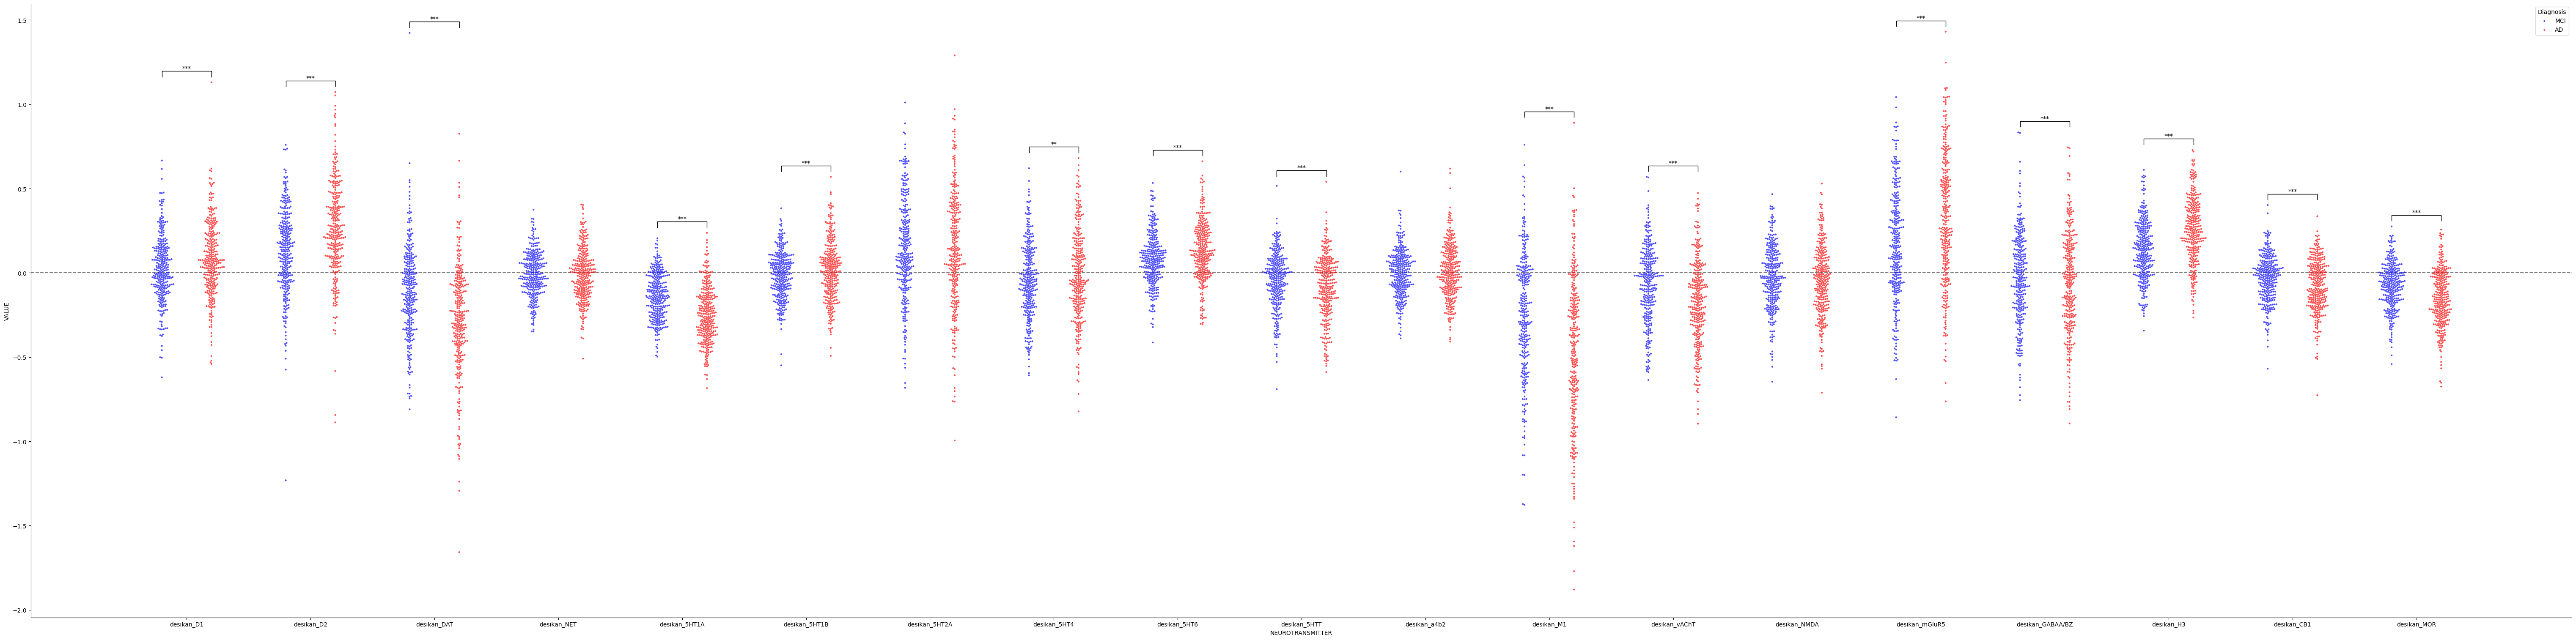

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import shapiro, wilcoxon
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

os.makedirs('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots/', exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


coeff_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_far.csv'

df = pd.read_csv(coeff_path, low_memory=False)

df = df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]

cleaned_df = df[df['DIAGNOSIS_oth'] == 1].reset_index(drop = True)
cleaned_df.drop(columns = 'DIAGNOSIS_oth', inplace = True)
cleaned_df.columns.tolist()

print(cleaned_df.isna().any().all())

root_cols = [col.replace('_mci','') for col in cleaned_df.columns.tolist() if col.endswith('_mci')]
print(root_cols)

stats_results = []
for c in root_cols:
    subset_df = cleaned_df[[col for col in cleaned_df.columns.tolist() if c in col]]
    is_normal = True
    for g in [cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values]:
        d = cleaned_df[f'{c}_mci'].values - cleaned_df[f'{c}_oth'].values
        res = shapiro(d)
        if res.pvalue < 0.05:
            is_normal = False
            break
    if is_normal:
        test_name = 'T-test related'
        _, pval, _ = ttest_rel(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
    else:
        test_name = 'Wilcoxon signed-rank'
        res = wilcoxon(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
        pval = res.pvalue

    stats_results.append({
    'Coefficient': c,
    'Raw_P': pval,
    'Test': test_name})
    
stats_df = pd.DataFrame(stats_results)
    
reject, p_corr, _, _ = multipletests(stats_df['Raw_P'], alpha=0.05, method='fdr_bh')
stats_df['Corrected_P'] = p_corr
stats_df['Significant'] = reject.tolist()#stats_df['Corrected_P'] < 0.05
print(stats_df)
stats_df.to_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', index = False)


cleaned_df = cleaned_df

mci_df = cleaned_df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']]
mci_df.columns = mci_df.columns.map(lambda x : x.replace('_mci', ''))
mci_df['DIAGNOSIS'] = 2
print(mci_df.columns.tolist())

ad_df = cleaned_df[['desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth',	'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]
ad_df.columns = ad_df.columns.map(lambda x : x.replace('_oth', ''))
ad_df['DIAGNOSIS'] = 3
print(ad_df.columns.tolist())

joined_df = pd.concat([mci_df, ad_df], axis = 0)

melted_df = joined_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

width = 61
height = max(6, float(width / 4))
dot_size = 3

stats_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', low_memory = False)

print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

plt.figure(figsize=(width, height))

v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()
        
ax = sns.swarmplot(
    data=melted_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {2: 'blue', 3: 'red'},
    dodge = True, 
    size = dot_size, 
    alpha = 0.7
) 

# Order + y positions
x_order = melted_df['NEUROTRANSMITTER'].unique()

y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
print(y_max)
        
        
y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)

y_total_range = v_max - v_min # Fix 1: Use existing global min/max
    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':
            
            y_base = y_max[nt] + 0.02 * y_total_range  
            y_tips = y_base - 0.01 * y_total_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)


sns.despine()
plt.legend(['MCI', 'AD'], loc = 'upper right', title = 'Diagnosis')
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
plt.tight_layout()
final_path = f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/swarmplots/cb_far_w{width}_h{height}_d{dot_size:.1f}.png"
print(final_path)
plt.savefig(final_path, dpi = 600)
plt.show()
plt.close()